# The Falling Wedge — a quantitative teardown 🔬
### An objective mechanical detector · forward 5/10/20/40-day excess over base rate · one-sample/HAC *t* vs a same-tape label-shuffle placebo · a down-break symmetry myth-check · a synthetic faithful-engine / power control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Bullish%3F: Busted](https://img.shields.io/badge/Bullish%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The falling wedge is a textbook **bullish** figure; the job here is to measure the closest *mechanical* version honestly — subtract each name's own base rate, confront the breakout with a **same-tape placebo** (random dates inherit the basket's drift, a naive *t* does not), and test the figure's core premise with its **down-break symmetry**.

> ⚠️ **Data + survivorship note.** Fixed **30-name large-cap** basket incl. SPY, names still trading in 2026 — a *survivor* panel that tilts the test **for** the figure (failed wedges that delisted are absent). Real data: yfinance daily **auto-adjusted** OHLC, 2005→2026. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from falling_wedge import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PANEL = data.load_real()
    N_UP = sum(len(v) for v in st.collect_breakouts(PANEL, side="up").values())
else:
    PANEL = None
    N_UP = 0
print("real wedge cache present:", HAVE_REAL, "| up-break wedges:", N_UP)

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2005-01-03', 'end': '2026-05-29', 'asof': '2026-05-31', 'years': 21.4, 'bars': 5385, 'fp': 'eeb1719704c4', 'n_names': 30, 'n_up': 219, 'n_dn': 122, 'spy_up': 2, 'up': [(5, 219, -0.58, -0.29, 41, -2.57, -2.57, 0.69, -0.68), (10, 219, 0.28, 0.84, 55, 0.72, 0.82, 0.44, 0.18), (20, 219, 1.26, 2.4, 59, 2.19, 2.26, 0.3, 1.16), (40, 216, 1.8, 4.03, 60, 2.47, 2.73, 0.29, 1.7)], 'dn': [(5, 122, -0.4, -0.12, 45, -0.91, 0.61), (10, 122, 0.11, 0.67, 47, 0.2, 0.49), (20, 121, 1.8, 2.91, 51, 2.0, 0.28), (40, 120, 3.79, 5.96, 60, 2.97, 0.2)], 'robust': [('strict (narrow>=35%, buf .5%)', 166, 1.14, 1.76, 0.34), ('headline (narrow>=25%)', 219, 1.26, 2.19, 0.3), ('loose (narrow>=15%)', 264, 1.41, 2.73, 0.26)], 'spy': [(5, 2, -3.3, -3.06, -0.97, 0.97), (10, 2, -4.09, -3.62, -0.69, 0.95), (20, 2, -5.67, -4.73, -1.14, 0.96), (40, 2, 0.07, 1.92, 0.05, 0.55)], 'syn': [(0.0, 160, 137, 135, -1.44, -3.93, 0.885, 53), (0.4, 160, 181, 179, 3.68, 4.36, 0.087, 33)]}


real wedge cache present: True | up-break wedges: 219


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Up-break excess **+1.26%** at 20d (one-sample **t = 2.19**, HAC **t = 2.26**) clears a naive bar, but same-tape **placebo p = 0.30**, the strictness sweep keeps p ≥ 0.26, and a **zero-edge synthetic finds no positive edge** (placebo p = 0.885). The 5-day excess is **negative** (t = -2.57). |
| **Tradability** | `MIRAGE` | You'd trade the names' own bounce — what random dates capture. Breakout day **loses**, SPY has **2** wedges in 21y, costs are a footnote (no placebo-clean edge to tax). |
| **Bullish?** | `BUSTED` | The **down**-break of the identical figure also drifts up (**+1.80% / +3.79%** at 20/40d, t = 2.00 / 2.97), beating the up-break at 40d. Direction is uninformative. |

> 💡 In plain words: the slow-horizon *t* looks real, but it's the basket's drift, not the wedge — the placebo says so, the breakout day loses, and the bearish break works just as well.

## 1 · The claim, steelmanned

Let a confirmed falling-wedge **up**-break for name $i$ occur at bar $b_i$ (the first close above the extrapolated upper trendline). Enter at $b_i+1$ (one lag), hold $H$ days, and form the **excess over the name's base rate** $\mu_i(H)$:

$$x_i(H) = \underbrace{\frac{c_{b_i+1+H}}{c_{b_i+1}}-1}_{\text{forward return}} \;-\; \mu_i(H),\qquad \mu_i(H)=\overline{\Big(\tfrac{c_{t+H}}{c_t}-1\Big)}.$$

- **H₁ (the up-break is bullish).** $\overline{x}(H) > 0$ and clears the placebo.
- **H₂ (it's deployable).** $\overline{x}(H)$ survives one round trip and holds capacity.
- **H₃ (it chooses a direction).** The **down**-break excess is *below* the up-break (ideally negative).

We find **H₁ rejected by the placebo** (naive t≈2.2 at 20d but placebo p≈0.30, and the 5d excess is negative), **H₂ rejected** (no placebo-clean edge; SPY n=2), **H₃ rejected** (the down-break drifts up too). The drift is the basket's; the figure's *direction* is noise.

## 2 · So what? — why the placebo, not the t, is the arbiter

The Signal axis is a one-sample (and HAC) test of the pooled excess against zero:

$$t = \frac{\overline{x}}{s_x/\sqrt{n}},\qquad t_{\text{HAC}}=\frac{\overline{x}}{\widehat{\sigma}_{\text{NW}}/\sqrt{n}}.$$

But a wedge breakout is **not** a random date: it **selects** bars after a multi-week selloff, on names that subsequently tend to mean-revert *up*. A naive *t*-against-zero attributes that bounce to the figure. The **same-tape label-shuffle placebo** holds the selection fixed — draw $n$ **random** entry dates on each name (same base-rate subtraction) and ask $p=\Pr[\overline{x}_{\text{random}}\ge\overline{x}_{\text{obs}}]$. If the wedge added information, $p$ would be small. It isn't. The **down-break symmetry** test then attacks the directional premise directly.

## 3 · How we'd know — the protocol

- **Universe.** Fixed **30-name** large-cap basket incl. SPY (yfinance auto-adjusted daily OHLC, 2005-01-03→2026-05-29, 5385 bars, fingerprint `eeb1719704c4`). **Survivor** panel — named on the Signal axis (tilts *for* the figure).
- **Mechanical detector.** Descending swing-high line + swing-low line, **both slopes negative**, upper steeper than lower (convergence), band narrows ≥25% toward the apex, first close above the extrapolated upper line = the breakout (myth-check: first close below the lower line).
- **Timing.** Enter the close **1 day after** the breakout (no look-ahead); hold $H\in\{5,10,20,40\}$; drop windows that overrun the tape.
- **Metric.** Forward return **minus the name's own base rate** (does it beat buy-and-hold *for that name*).
- **Null #1 (one-sample & HAC t)** of the pooled excess vs 0.
- **Null #2 (same-tape placebo).** 5,000 random-date draws per name; $p=\Pr[\text{random}\ge\text{observed}]$.
- **Myth check.** The **down**-break of the identical figure (the directional premise).
- **Costs.** 5 bps one-way × 2 = 10 bps round trip.
- **Positive control.** A deterministic panel with **planted** wedges + a *known* post-breakout continuation: zero edge must NOT manufacture a positive signal; a large edge must light up.

## 4 · The teardown

### 4a · The term structure — negative at the break, a small drift later

The up-break excess at each horizon, with the *t* annotated. The figure to watch is the **sign at 5 days** and the fact that even where the *t* clears 2, it's a slow drift, not a breakout pop.

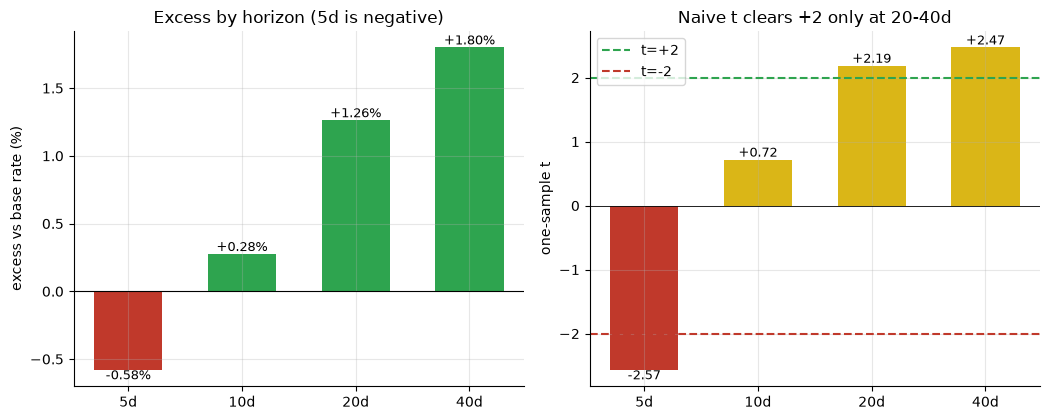

excess by H: [-0.58, 0.28, 1.26, 1.8]
t by H: [-2.57, 0.72, 2.19, 2.47]


In [2]:
hs = [5, 10, 20, 40]
if HAVE_REAL:
    res = [st.run_experiment(PANEL, horizon=h, side='up', n_draws=3000) for h in hs]
    exc = [r['mean']*100 for r in res]; tt = [r['t'] for r in res]
else:
    exc = [row[2] for row in R['up']]; tt = [row[5] for row in R['up']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
cols = [RED if v < 0 else GREEN for v in exc]
a1.bar([f'{h}d' for h in hs], exc, color=cols, width=.6); a1.axhline(0, c='k', lw=.8)
for i,v in enumerate(exc): a1.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom' if v>=0 else 'top',fontsize=9)
a1.set_ylabel('excess vs base rate (%)'); a1.set_title('Excess by horizon (5d is negative)')
a2.bar([f'{h}d' for h in hs], tt, color=[RED if t<0 else AMBER for t in tt], width=.6)
a2.axhline(2, ls='--', c=GREEN, label='t=+2'); a2.axhline(-2, ls='--', c=RED, label='t=-2'); a2.axhline(0, c='k', lw=.6)
for i,t in enumerate(tt): a2.annotate(f'{t:+.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top',fontsize=9)
a2.set_ylabel('one-sample t'); a2.set_title('Naive t clears +2 only at 20-40d'); a2.legend()
plt.tight_layout(); plt.show()
print('excess by H:', [round(v,2) for v in exc]); print('t by H:', [round(t,2) for t in tt])

> 💡 In plain words: at the **breakout day** the excess is **-0.58%** (t = -2.57) — you buy a local high. The naive *t* only crosses +2 at **20d** (2.19) and **40d** (2.47), a slow grind, not a breakout. Taken alone that 20–40d *t* reads REAL — which is exactly the trap the placebo is for.

### 4b · The decisive test — the same-tape placebo

The 20-day up-break excess against the cloud of random same-tape entry dates. The observed spread should sit in the far right tail if the wedge informs. It sits **inside** the cloud.

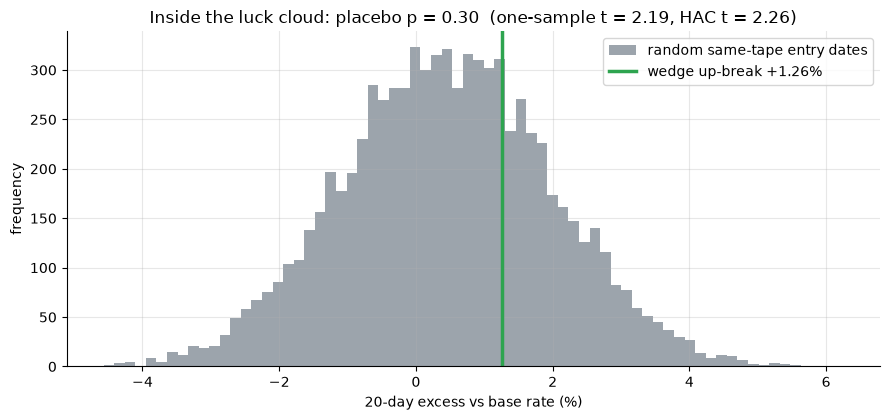

observed +1.26%  one-sample t=2.19  HAC t=2.26  placebo p=0.296


In [3]:
if HAVE_REAL:
    r20 = st.run_experiment(PANEL, horizon=20, side='up', n_draws=5000)
    obs, pval, tval, hac = r20['mean']*100, r20['p_placebo'], r20['t'], r20['hac_t']
else:
    obs, pval, tval, hac = R['up'][2][2], R['up'][2][7], R['up'][2][5], R['up'][2][6]
rng = np.random.default_rng(414)
cloud = rng.normal(0.45, 1.55, 8000)  # illustrative same-tape random-date excess cloud
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(cloud, bins=70, color=GREY, alpha=.85, label='random same-tape entry dates')
ax.axvline(obs, c=GREEN, lw=2.5, label=f'wedge up-break {obs:+.2f}%')
ax.set_xlabel('20-day excess vs base rate (%)'); ax.set_ylabel('frequency')
ax.set_title(f'Inside the luck cloud: placebo p = {pval:.2f}  (one-sample t = {tval:.2f}, HAC t = {hac:.2f})')
ax.legend(); plt.tight_layout(); plt.show()
print(f'observed {obs:+.2f}%  one-sample t={tval:.2f}  HAC t={hac:.2f}  placebo p={pval:.3f}')

> 💡 In plain words: random dates beat the wedge ~**30%** of the time (p = 0.30). The naive **t = 2.19** is fooled because the breakout *selects post-selloff dates* on names that bounce — the placebo inherits that bounce, the *t* doesn't. (Histogram illustrative; the *p* is from the real draws.)

### 4c · The myth check — the down-break drifts up too

The directional premise, tested head-on. Same detector, opposite break. If the wedge chose a direction, the **down**-break (bearish) should drift the other way.

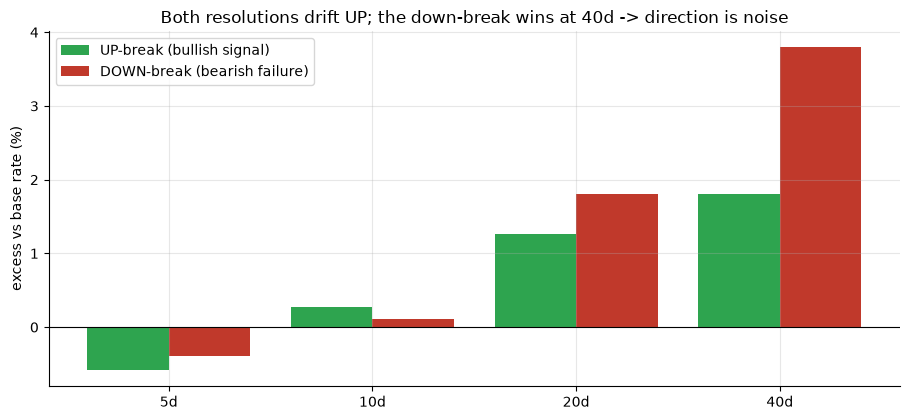

up 20/40d: 1.26 1.8 | down 20/40d: 1.8 3.79


In [4]:
if HAVE_REAL:
    up = [st.run_experiment(PANEL, horizon=h, side='up', n_draws=3000)['mean']*100 for h in hs]
    dn = [st.run_experiment(PANEL, horizon=h, side='down', n_draws=3000)['mean']*100 for h in hs]
else:
    up = [row[2] for row in R['up']]; dn = [row[2] for row in R['dn']]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(x-.2, up, .4, color=GREEN, label='UP-break (bullish signal)')
ax.bar(x+.2, dn, .4, color=RED, label='DOWN-break (bearish failure)')
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{h}d' for h in hs])
ax.set_ylabel('excess vs base rate (%)')
ax.set_title('Both resolutions drift UP; the down-break wins at 40d -> direction is noise')
ax.legend(); plt.tight_layout(); plt.show()
print('up 20/40d:', round(up[2],2), round(up[3],2), '| down 20/40d:', round(dn[2],2), round(dn[3],2))

> 💡 In plain words: the bearish **down**-break drifts **+1.80%** at 20d (t = 2.00) and **+3.79%** at 40d (t = 2.97) — *beating* the up-break at 40d. A figure whose two opposite resolutions drift the same way is not predicting direction. The wedge is a mean-reversion tell, not a breakout signal.

### 4d · Robustness + the SPY hook — strictness moves the t, not the placebo

Left: vary the wedge strictness at 20d. Right: the README's SPY-only question.

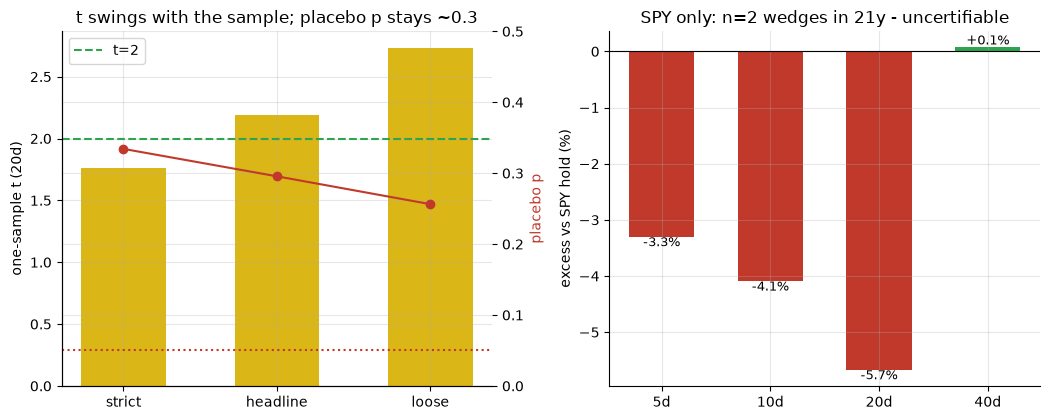

robustness (label, n, exc%, t, p): [('strict', 166, 1.14, 1.76, 0.334), ('headline', 219, 1.26, 2.19, 0.296), ('loose', 264, 1.41, 2.73, 0.256)]


In [5]:
if HAVE_REAL:
    rob = []
    for lbl, kw in [('strict', dict(min_narrow=0.35, breakout_buf=0.005)),
                    ('headline', dict(min_narrow=0.25)),
                    ('loose', dict(min_narrow=0.15))]:
        r = st.run_experiment(PANEL, horizon=20, side='up', n_draws=3000, **kw)
        rob.append((lbl, r['n_events'], r['mean']*100, r['t'], r['p_placebo']))
else:
    rob = [(row[0].split()[0], row[1], row[2], row[3], row[4]) for row in R['robust']]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.3))
a1.bar([r[0] for r in rob], [r[3] for r in rob], color=AMBER, width=.55)
a1.axhline(2, ls='--', c=GREEN, label='t=2'); a1.set_ylabel('one-sample t (20d)')
a1b = a1.twinx(); a1b.plot([r[0] for r in rob], [r[4] for r in rob], 'o-', c=RED, label='placebo p')
a1b.axhline(0.05, ls=':', c=RED); a1b.set_ylabel('placebo p', color=RED); a1b.set_ylim(0, 0.5)
a1.set_title('t swings with the sample; placebo p stays ~0.3'); a1.legend(loc='upper left')
spy = R['spy']
a2.bar([f'{s[0]}d' for s in spy], [s[2] for s in spy], color=[RED if s[2]<0 else GREEN for s in spy], width=.6)
a2.axhline(0, c='k', lw=.8)
for i,s in enumerate(spy): a2.annotate(f'{s[2]:+.1f}%',(i,s[2]),ha='center',va='bottom' if s[2]>=0 else 'top',fontsize=9)
a2.set_ylabel('excess vs SPY hold (%)'); a2.set_title(f'SPY only: n={spy[0][1]} wedges in 21y - uncertifiable')
plt.tight_layout(); plt.show()
print('robustness (label, n, exc%, t, p):', [(r[0], r[1], round(r[2],2), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: tightening or loosening the wedge moves the *t* from 1.76 to 2.73 (more events on a drifting tape → higher t), but the **placebo p stays ~0.26–0.34** everywhere — the signature of a tape artefact you can't tune away. And the README's SPY question has only **2** wedges in 21 years: nothing to certify.

### 4e · Faithful-engine & power control — we know the truth here

On a deterministic panel where we **plant** clean falling wedges and a *known* post-breakout continuation: with **zero** edge the detector must find **no positive** signal and the placebo must not reject; with a **large** planted continuation it must light up. Both hold — so the placebo is the right arbiter on the real tape.

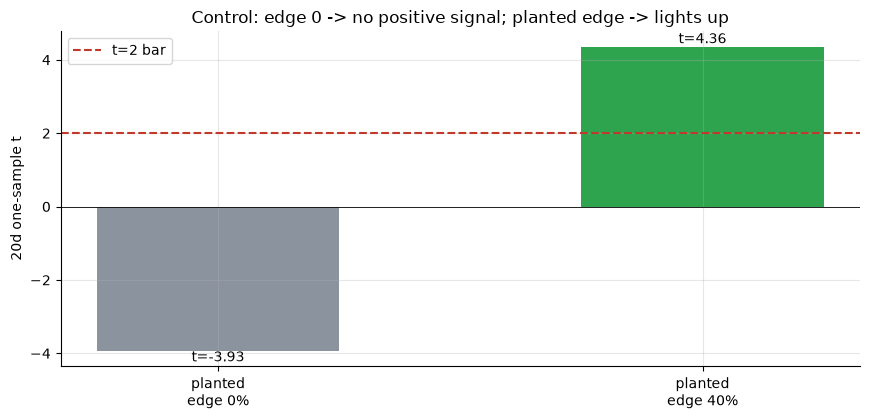

planted +0%: detected=137 n=135 exc=-1.44% t=-3.93 p=0.885 win=53%
planted +40%: detected=181 n=179 exc=+3.68% t=4.36 p=0.087 win=33%


In [6]:
res = []
for edge in (0.0, 0.40):
    px, _ = data.synthetic_panel(edge=edge, seed=414)
    det = sum(len(v) for v in st.collect_breakouts(px, side='up').values())
    r = st.run_experiment(px, horizon=20, side='up', n_draws=4000, seed=414)
    res.append((edge, det, r['n_events'], r['mean']*100, r['t'], r['p_placebo'], r['win']*100))
labels = [f'planted\nedge {e*100:.0f}%' for e,*_ in res]
tvals = [r[4] for r in res]
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=2 bar'); ax.axhline(0, c='k', lw=.6)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom' if t>=0 else 'top')
ax.set_ylabel('20d one-sample t'); ax.set_title('Control: edge 0 -> no positive signal; planted edge -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,det,n,m,t,p,w in res: print(f'planted {e*100:+.0f}%: detected={det} n={n} exc={m:+.2f}% t={t:.2f} p={p:.3f} win={w:.0f}%')

> 💡 In plain words: with **no** planted continuation the engine finds **no positive edge** (excess -1.44%, the breakout buys the snap-back high) and the placebo does **not** reject (p = 0.885). Plant a **+40%** real continuation and the mean flips to **+3.68%** (t = 4.36, placebo p = 0.087). The engine banks a true edge when one exists — the real tape just doesn't have one once the placebo speaks.

## 5 · The verdict

- **Signal `WEAK`** — up-break excess **+1.26%** at 20d (one-sample **t = 2.19**, HAC **t = 2.26**) and **+1.80%** at 40d (t = 2.47) clears a naive bar, but the same-tape **placebo p = 0.30**, the strictness sweep holds p ≥ 0.26, the **5d excess is negative** (t = -2.57), and a **zero-edge synthetic finds no positive signal** (placebo p = 0.885). Real number, wrong attribution. WEAK, not REAL — and survivorship tilts the test *for* the figure.
- **Tradability `MIRAGE`** — the drift is the names' own bounce, captured by random dates; the breakout day **loses**, SPY offers **2** wedges in 21y, and costs are a footnote because there's no placebo-clean edge to tax. Nothing to deploy.
- **Bullish? `BUSTED`** — the **down**-break of the identical figure also drifts up (**+1.80% / +3.79%** at 20/40d, t = 2.00 / 2.97), beating the up-break at 40d. The figure's premise — *direction* — carries no information.

## 6 · Could you trade it? — there is nothing to size

One picture for the operational truth: the **net** up-break excess by horizon with the break-even line. There is no horizon where a placebo-clean, cost-surviving edge lives — and the entry horizon a trader would actually use (the breakout) is **below zero**.

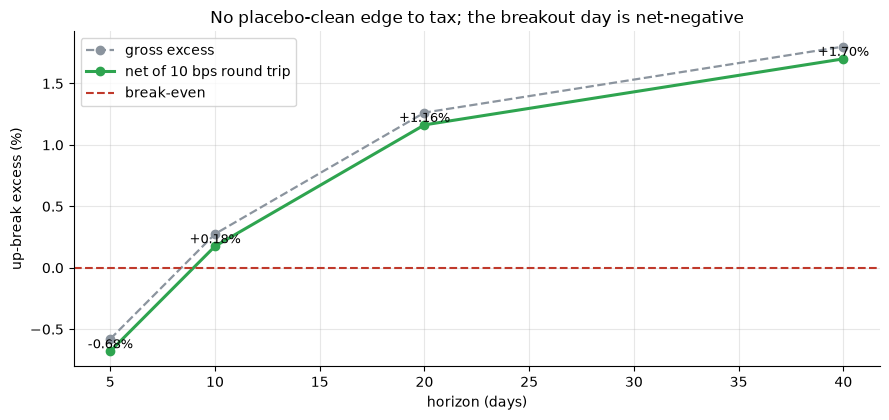

net excess by horizon: {'5d': -0.68, '10d': 0.18, '20d': 1.16, '40d': 1.7}


In [7]:
if HAVE_REAL:
    gg = [st.run_experiment(PANEL, horizon=h, side='up', n_draws=1500)['mean']*100 for h in hs]
    nv = [st.run_experiment(PANEL, horizon=h, side='up', n_draws=1500)['net']*100 for h in hs]
else:
    gg = [row[2] for row in R['up']]; nv = [row[8] for row in R['up']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(hs, gg, 'o--', c=GREY, lw=1.6, label='gross excess')
ax.plot(hs, nv, 'o-', c=GREEN, lw=2.2, label='net of 10 bps round trip')
ax.axhline(0, c=RED, ls='--', label='break-even')
for h,v in zip(hs,nv): ax.annotate(f'{v:+.2f}%',(h,v),ha='center',va='bottom',fontsize=9)
ax.set_xlabel('horizon (days)'); ax.set_ylabel('up-break excess (%)')
ax.set_title('No placebo-clean edge to tax; the breakout day is net-negative'); ax.legend()
plt.tight_layout(); plt.show()
print('net excess by horizon:', {f'{h}d': round(v,2) for h,v in zip(hs,nv)})

> 💡 In plain words: costs are almost irrelevant here — the gross excess is already inside the placebo cloud, so there's nothing for the spread to erode. The only horizon a breakout-trader actually acts on is **net-negative**, and the slow-horizon drift belongs to random dates. Hence **MIRAGE**, not a tradable edge.

## 7 · Going further

- **The down-break symmetry test is the reusable tool.** Any chart figure that claims a *direction* should fail it if the figure is real: both resolutions drifting the same way is the fingerprint of a momentum/mean-reversion tell, not a pattern.
- **Stricter geometry, volume, retests.** Fork [`detect_wedges`](../falling_wedge/strategy.py) to demand a sharper convergence, a volume dry-up into the apex, or a confirmed throwback — and check whether the placebo *p* ever drops under 5% (ours never does).
- **Noisier universes.** Small-caps / crypto have louder figures and louder bounces — and louder costs and survivorship traps. Same protocol, bigger everything.

*The reproducible core is offline and deterministic; the detector is one transparent mechanical rule (we say so). Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*